In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/kartthikc18/weatheraus/weatherAUS.csv


In [2]:
# ── 0. IMPORTS ───────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
 
# Sklearn
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import RobustScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.metrics import (
    roc_auc_score, f1_score, average_precision_score,
    confusion_matrix, classification_report, accuracy_score,
    roc_curve, precision_recall_curve, ConfusionMatrixDisplay
)
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
 
# Imbalance
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
 
# XGBoost
from xgboost import XGBClassifier
 
# Deep Learning
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks
from tensorflow.keras.models import Sequential
 
print("All imports successful ✓")
print(f"TensorFlow version: {tf.__version__}")

2026-04-12 08:30:57.578114: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775982657.601819     198 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775982657.609721     198 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775982657.628098     198 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775982657.628125     198 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775982657.628127     198 computation_placer.cc:177] computation placer alr

All imports successful ✓
TensorFlow version: 2.19.0


In [3]:
# ── 1. LOAD DATA ─────────────────────────────────────────────
path = "/kaggle/input/datasets/kartthikc18/weatheraus/weatherAUS.csv"
df = pd.read_csv(path)
print(f"\nDataset shape: {df.shape}")
print(df.head(3))


Dataset shape: (142193, 24)
         Date Location  MinTemp  MaxTemp  Rainfall  Evaporation  Sunshine  \
0  2008-12-01   Albury     13.4     22.9       0.6          NaN       NaN   
1  2008-12-02   Albury      7.4     25.1       0.0          NaN       NaN   
2  2008-12-03   Albury     12.9     25.7       0.0          NaN       NaN   

  WindGustDir  WindGustSpeed WindDir9am  ... Humidity3pm  Pressure9am  \
0           W           44.0          W  ...        22.0       1007.7   
1         WNW           44.0        NNW  ...        25.0       1010.6   
2         WSW           46.0          W  ...        30.0       1007.6   

   Pressure3pm  Cloud9am  Cloud3pm  Temp9am  Temp3pm  RainToday  RISK_MM  \
0       1007.1       8.0       NaN     16.9     21.8         No      0.0   
1       1007.8       NaN       NaN     17.2     24.3         No      0.0   
2       1008.7       NaN       2.0     21.0     23.2         No      0.0   

   RainTomorrow  
0            No  
1            No  
2         

In [4]:
# ── 2. DROP LEAKAGE & IRRELEVANT COLUMNS ─────────────────────
# RISK_MM directly encodes tomorrow's rainfall → data leakage
df.drop(columns=["RISK_MM"], inplace=True)
print("\nDropped RISK_MM (data leakage). Remaining columns:", df.shape[1])


Dropped RISK_MM (data leakage). Remaining columns: 23


In [5]:
# ── 3. FEATURE ENGINEERING FROM DATE ─────────────────────────
df["Date"] = pd.to_datetime(df["Date"])
df["Month"]  = df["Date"].dt.month
df["Year"]   = df["Date"].dt.year
 
def get_season(month):
    """Australian meteorological seasons."""
    if month in [12, 1, 2]:  return "Summer"
    elif month in [3, 4, 5]:  return "Autumn"
    elif month in [6, 7, 8]:  return "Winter"
    else:                      return "Spring"
 
df["Season"] = df["Month"].apply(get_season)
df.drop(columns=["Date"], inplace=True)
print("Extracted Month, Year, Season from Date ✓")

Extracted Month, Year, Season from Date ✓


In [6]:
# ── 4. ENCODE TARGET ─────────────────────────────────────────
df["RainTomorrow"] = df["RainTomorrow"].map({"Yes": 1, "No": 0})
df["RainToday"]    = df["RainToday"].map({"Yes": 1, "No": 0})
 
# Drop rows where target is NaN
df.dropna(subset=["RainTomorrow"], inplace=True)
print(f"After dropping NaN targets → shape: {df.shape}")
print(f"Class distribution:\n{df['RainTomorrow'].value_counts()}")

After dropping NaN targets → shape: (142193, 25)
Class distribution:
RainTomorrow
0    110316
1     31877
Name: count, dtype: int64


In [7]:
# ── 5. CYCLICAL ENCODING FOR WIND DIRECTION ──────────────────
WIND_DIRS = ["WindGustDir", "WindDir9am", "WindDir3pm"]
compass_map = {
    "N": 0, "NNE": 22.5, "NE": 45, "ENE": 67.5,
    "E": 90, "ESE": 112.5, "SE": 135, "SSE": 157.5,
    "S": 180, "SSW": 202.5, "SW": 225, "WSW": 247.5,
    "W": 270, "WNW": 292.5, "NW": 315, "NNW": 337.5
}
 
for col in WIND_DIRS:
    deg = df[col].map(compass_map)
    df[col + "_sin"] = np.sin(np.deg2rad(deg))
    df[col + "_cos"] = np.cos(np.deg2rad(deg))
    df.drop(columns=[col], inplace=True)
 
print("Cyclical wind direction encoding done ✓")

Cyclical wind direction encoding done ✓


In [8]:
# ── 7. ENCODE SEASON ─────────────────────────────────────────
season_dummies = pd.get_dummies(df["Season"], prefix="Season", drop_first=True).astype(int)
df = pd.concat([df, season_dummies], axis=1)
df.drop(columns=["Season"], inplace=True)
print("Season one-hot encoded ✓")

Season one-hot encoded ✓


In [9]:
# ── 8. TRAIN / TEST SPLIT (before imputation to prevent leakage) ──
X = df.drop(columns=["RainTomorrow"])
y = df["RainTomorrow"].astype(int)
 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"\nTrain size: {X_train.shape}, Test size: {X_test.shape}")


Train size: (113754, 29), Test size: (28439, 29)


In [10]:
# ── 9. TARGET ENCODE LOCATION (fit on train only) ────────────
loc_target_map = (
    X_train.join(y_train)
    .groupby("Location")["RainTomorrow"]
    .mean()
    .to_dict()
)
global_mean = y_train.mean()
 
X_train["Location"] = X_train["Location"].map(loc_target_map).fillna(global_mean)
X_test["Location"]  = X_test["Location"].map(loc_target_map).fillna(global_mean)
print("Target encoding for Location done (fit on train only) ✓")

Target encoding for Location done (fit on train only) ✓


In [11]:
# ── 10. IMPUTATION (fit on train only) ───────────────────────
num_cols = X_train.select_dtypes(include=np.number).columns.tolist()
cat_cols = X_train.select_dtypes(exclude=np.number).columns.tolist()
print(f"\nNumerical cols ({len(num_cols)}): {num_cols}")
print(f"Categorical cols ({len(cat_cols)}): {cat_cols}")
 
# Numerical → median imputation grouped by (implicit via SimpleImputer on full set)
num_imputer = SimpleImputer(strategy="median")
X_train[num_cols] = num_imputer.fit_transform(X_train[num_cols])
X_test[num_cols]  = num_imputer.transform(X_test[num_cols])
 
# Remaining categoricals (if any) → mode
if cat_cols:
    cat_imputer = SimpleImputer(strategy="most_frequent")
    X_train[cat_cols] = cat_imputer.fit_transform(X_train[cat_cols])
    X_test[cat_cols]  = cat_imputer.transform(X_test[cat_cols])
 
print("Imputation complete ✓")


Numerical cols (29): ['Location', 'MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation', 'Sunshine', 'WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm', 'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm', 'Temp9am', 'Temp3pm', 'RainToday', 'Month', 'Year', 'WindGustDir_sin', 'WindGustDir_cos', 'WindDir9am_sin', 'WindDir9am_cos', 'WindDir3pm_sin', 'WindDir3pm_cos', 'Season_Spring', 'Season_Summer', 'Season_Winter']
Categorical cols (0): []
Imputation complete ✓


In [12]:
# ── 11. SCALING ───────────────────────────────────────────────
scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)
print("RobustScaler applied ✓")

RobustScaler applied ✓


In [13]:
# ── 12. SMOTE (on training set only) ─────────────────────────
smote = SMOTE(random_state=42, k_neighbors=5)
X_train_res, y_train_res = smote.fit_resample(X_train_scaled, y_train)
print(f"\nAfter SMOTE → X_train: {X_train_res.shape}")
print(f"Class distribution after SMOTE: {pd.Series(y_train_res).value_counts().to_dict()}")


After SMOTE → X_train: (176504, 29)
Class distribution after SMOTE: {0: 88252, 1: 88252}


In [14]:
# ── 13. HELPER: EVALUATION FUNCTION ──────────────────────────
def evaluate_model(name, y_true, y_pred, y_proba):
    """Print and return all evaluation metrics."""
    acc    = accuracy_score(y_true, y_pred)
    f1     = f1_score(y_true, y_pred, average="macro")
    roc    = roc_auc_score(y_true, y_proba)
    pr_auc = average_precision_score(y_true, y_proba)
    cm     = confusion_matrix(y_true, y_pred)
 
    print(f"\n{'='*55}")
    print(f"  {name}")
    print(f"{'='*55}")
    print(f"  Accuracy  : {acc:.4f}")
    print(f"  F1 (macro): {f1:.4f}")
    print(f"  ROC-AUC   : {roc:.4f}")
    print(f"  PR-AUC    : {pr_auc:.4f}")
    print(f"\nClassification Report:\n{classification_report(y_true, y_pred)}")
 
    return {"name": name, "accuracy": acc, "f1": f1,
            "roc_auc": roc, "pr_auc": pr_auc,
            "cm": cm, "y_proba": y_proba, "y_pred": y_pred}

In [15]:
# ── 14. MODEL 1 — LOGISTIC REGRESSION ────────────────────────
print("\n>>> Training Logistic Regression...")
lr = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    solver="saga",
    random_state=42,
    n_jobs=-1
)
lr.fit(X_train_res, y_train_res)
lr_pred   = lr.predict(X_test_scaled)
lr_proba  = lr.predict_proba(X_test_scaled)[:, 1]
lr_results = evaluate_model("Logistic Regression", y_test, lr_pred, lr_proba)


>>> Training Logistic Regression...

  Logistic Regression
  Accuracy  : 0.7917
  F1 (macro): 0.7397
  ROC-AUC   : 0.8676
  PR-AUC    : 0.6939

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.80      0.86     22064
           1       0.52      0.77      0.62      6375

    accuracy                           0.79     28439
   macro avg       0.72      0.78      0.74     28439
weighted avg       0.83      0.79      0.80     28439



In [16]:
# ── 15. MODEL 2 — RANDOM FOREST ──────────────────────────────
print("\n>>> Training Random Forest...")
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=20,
    min_samples_leaf=4,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train_res, y_train_res)
rf_pred   = rf.predict(X_test_scaled)
rf_proba  = rf.predict_proba(X_test_scaled)[:, 1]
rf_results = evaluate_model("Random Forest", y_test, rf_pred, rf_proba)


>>> Training Random Forest...

  Random Forest
  Accuracy  : 0.8473
  F1 (macro): 0.7812
  ROC-AUC   : 0.8922
  PR-AUC    : 0.7384

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.90      0.90     22064
           1       0.66      0.66      0.66      6375

    accuracy                           0.85     28439
   macro avg       0.78      0.78      0.78     28439
weighted avg       0.85      0.85      0.85     28439



In [17]:
# ── 16. MODEL 3 — XGBOOST ────────────────────────────────────
print("\n>>> Training XGBoost...")
neg_pos_ratio = (y_train_res == 0).sum() / (y_train_res == 1).sum()
 
xgb = XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=neg_pos_ratio,   # handles imbalance
    use_label_encoder=False,
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1,
    tree_method="hist"                 # faster on Kaggle CPU/GPU
)
xgb.fit(
    X_train_res, y_train_res,
    eval_set=[(X_test_scaled, y_test)],
    verbose=100
)
xgb_pred  = xgb.predict(X_test_scaled)
xgb_proba = xgb.predict_proba(X_test_scaled)[:, 1]
xgb_results = evaluate_model("XGBoost", y_test, xgb_pred, xgb_proba)


>>> Training XGBoost...
[0]	validation_0-logloss:0.67453
[100]	validation_0-logloss:0.37157
[200]	validation_0-logloss:0.34206
[300]	validation_0-logloss:0.33007
[400]	validation_0-logloss:0.32316
[499]	validation_0-logloss:0.31857

  XGBoost
  Accuracy  : 0.8620
  F1 (macro): 0.7822
  ROC-AUC   : 0.8977
  PR-AUC    : 0.7588

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.95      0.91     22064
           1       0.75      0.57      0.65      6375

    accuracy                           0.86     28439
   macro avg       0.82      0.76      0.78     28439
weighted avg       0.85      0.86      0.85     28439



In [18]:
# ── 17. MODEL 4 — DEEP FEEDFORWARD NEURAL NETWORK ────────────
print("\n>>> Training Deep FFNN...")
n_features = X_train_res.shape[1]
 
def build_ffnn(input_dim):
    model = Sequential([
        layers.Input(shape=(input_dim,)),
 
        # Block 1
        layers.Dense(256, kernel_initializer="he_normal"),
        layers.BatchNormalization(),
        layers.Activation("relu"),
        layers.Dropout(0.3),
 
        # Block 2
        layers.Dense(128, kernel_initializer="he_normal"),
        layers.BatchNormalization(),
        layers.Activation("relu"),
        layers.Dropout(0.3),
 
        # Block 3
        layers.Dense(64, kernel_initializer="he_normal"),
        layers.BatchNormalization(),
        layers.Activation("relu"),
        layers.Dropout(0.2),
 
        # Block 4
        layers.Dense(32, kernel_initializer="he_normal"),
        layers.BatchNormalization(),
        layers.Activation("relu"),
        layers.Dropout(0.2),
 
        # Output
        layers.Dense(1, activation="sigmoid")
    ])
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss="binary_crossentropy",
        metrics=["accuracy", keras.metrics.AUC(name="auc")]
    )
    return model
 
ffnn = build_ffnn(n_features)
ffnn.summary()
 
# Class weights for FFNN (SMOTE already balanced, but keep for safety)
class_weight_dict = {0: 1.0, 1: 1.0}
 
cb_list = [
    callbacks.EarlyStopping(
        monitor="val_auc", patience=10,
        restore_best_weights=True, mode="max"
    ),
    callbacks.ReduceLROnPlateau(
        monitor="val_loss", factor=0.5,
        patience=5, min_lr=1e-6, verbose=1
    )
]
 
history = ffnn.fit(
    X_train_res, y_train_res,
    validation_data=(X_test_scaled, y_test),
    epochs=100,
    batch_size=1024,
    callbacks=cb_list,
    class_weight=class_weight_dict,
    verbose=1
)
 
ffnn_proba = ffnn.predict(X_test_scaled, batch_size=1024).ravel()
ffnn_pred  = (ffnn_proba >= 0.5).astype(int)
ffnn_results = evaluate_model("FFNN", y_test, ffnn_pred, ffnn_proba)
 


>>> Training Deep FFNN...


I0000 00:00:1775982907.077182     198 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1775982907.083012     198 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │         7,680 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 52,865 (206.50 KB)

...

Epoch 1/100


I0000 00:00:1775982911.471891     320 service.cc:152] XLA service 0x7d423c006c60 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1775982911.471926     320 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1775982911.471930     320 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1775982912.107005     320 cuda_dnn.cc:529] Loaded cuDNN version 91002


 47/173 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6272 - auc: 0.6824 - loss: 0.6457

I0000 00:00:1775982916.416037     320 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


173/173 ━━━━━━━━━━━━━━━━━━━━ 14s 38ms/step - accuracy: 0.6984 - auc: 0.7695 - loss: 0.5725 - val_accuracy: 0.7742 - val_auc: 0.8667 - val_loss: 0.4672 - learning_rate: 0.0010
Epoch 2/100
173/173 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7813 - auc: 0.8605 - loss: 0.4675 - val_accuracy: 0.7957 - val_auc: 0.8747 - val_loss: 0.4321 - learning_rate: 0.0010
Epoch 3/100
173/173 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7916 - auc: 0.8722 - loss: 0.4485 - val_accuracy: 0.7932 - val_auc: 0.8777 - val_loss: 0.4362 - learning_rate: 0.0010
Epoch 4/100
173/173 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7968 - auc: 0.8774 - loss: 0.4398 - val_accuracy: 0.7886 - val_auc: 0.8795 - val_loss: 0.4484 - learning_rate: 0.0010
Epoch 5/100
173/173 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7994 - auc: 0.8812 - loss: 0.4337 - val_accuracy: 0.7879 - val_auc: 0.8809 - val_loss: 0.4412 - learning_rate: 0.0010
Epoch 6/100
173/173 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8030 - auc: 0.8837

In [19]:
# ── 18. ENSEMBLE — WEIGHTED SOFT VOTING ──────────────────────
# Weights assigned based on individual ROC-AUC scores
print("\n>>> Building Weighted Soft Voting Ensemble...")
 
roc_scores = np.array([
    lr_results["roc_auc"],
    rf_results["roc_auc"],
    xgb_results["roc_auc"],
    ffnn_results["roc_auc"]
])
# Normalise weights so they sum to 1
weights = roc_scores / roc_scores.sum()
print(f"Model weights (ROC-AUC normalised): LR={weights[0]:.3f} | RF={weights[1]:.3f} | "
      f"XGB={weights[2]:.3f} | FFNN={weights[3]:.3f}")
 
# Stack all probability predictions
all_probas = np.column_stack([
    lr_proba,
    rf_proba,
    xgb_proba,
    ffnn_proba
])
 
# Weighted average of probabilities
ensemble_proba = np.average(all_probas, axis=1, weights=weights)
ensemble_pred  = (ensemble_proba >= 0.5).astype(int)
ensemble_results = evaluate_model(
    "Weighted Soft Voting Ensemble",
    y_test, ensemble_pred, ensemble_proba
)


>>> Building Weighted Soft Voting Ensemble...
Model weights (ROC-AUC normalised): LR=0.245 | RF=0.252 | XGB=0.253 | FFNN=0.250

  Weighted Soft Voting Ensemble
  Accuracy  : 0.8415
  F1 (macro): 0.7829
  ROC-AUC   : 0.8944
  PR-AUC    : 0.7511

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.88      0.90     22064
           1       0.63      0.72      0.67      6375

    accuracy                           0.84     28439
   macro avg       0.77      0.80      0.78     28439
weighted avg       0.85      0.84      0.85     28439




>>> Generating visualisation plots...


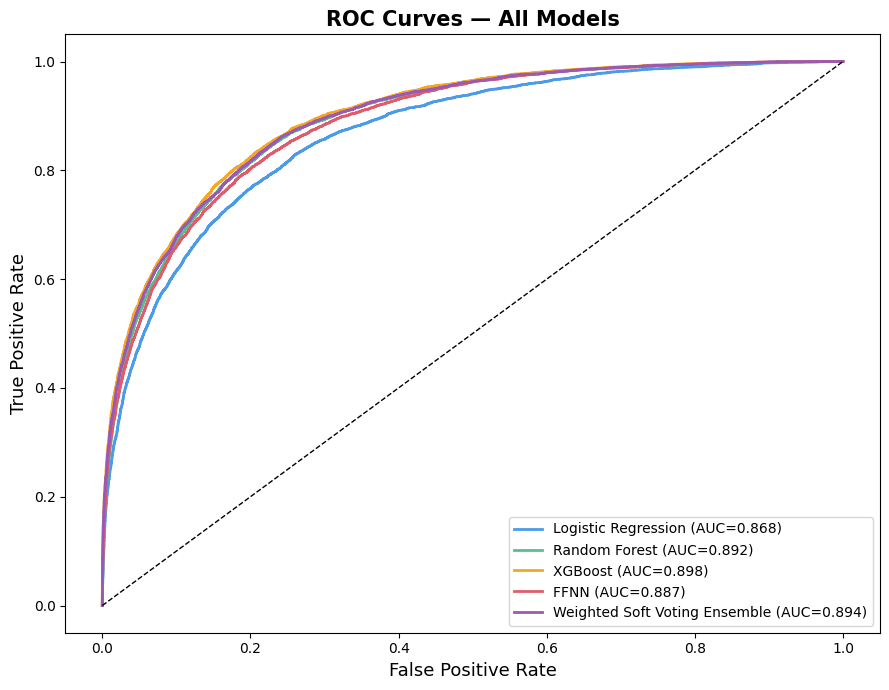

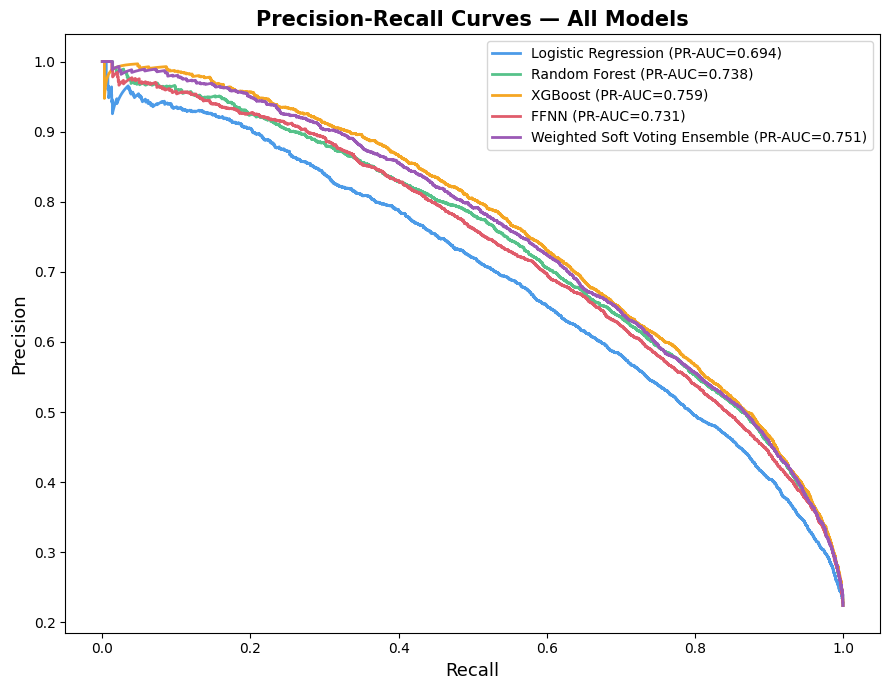

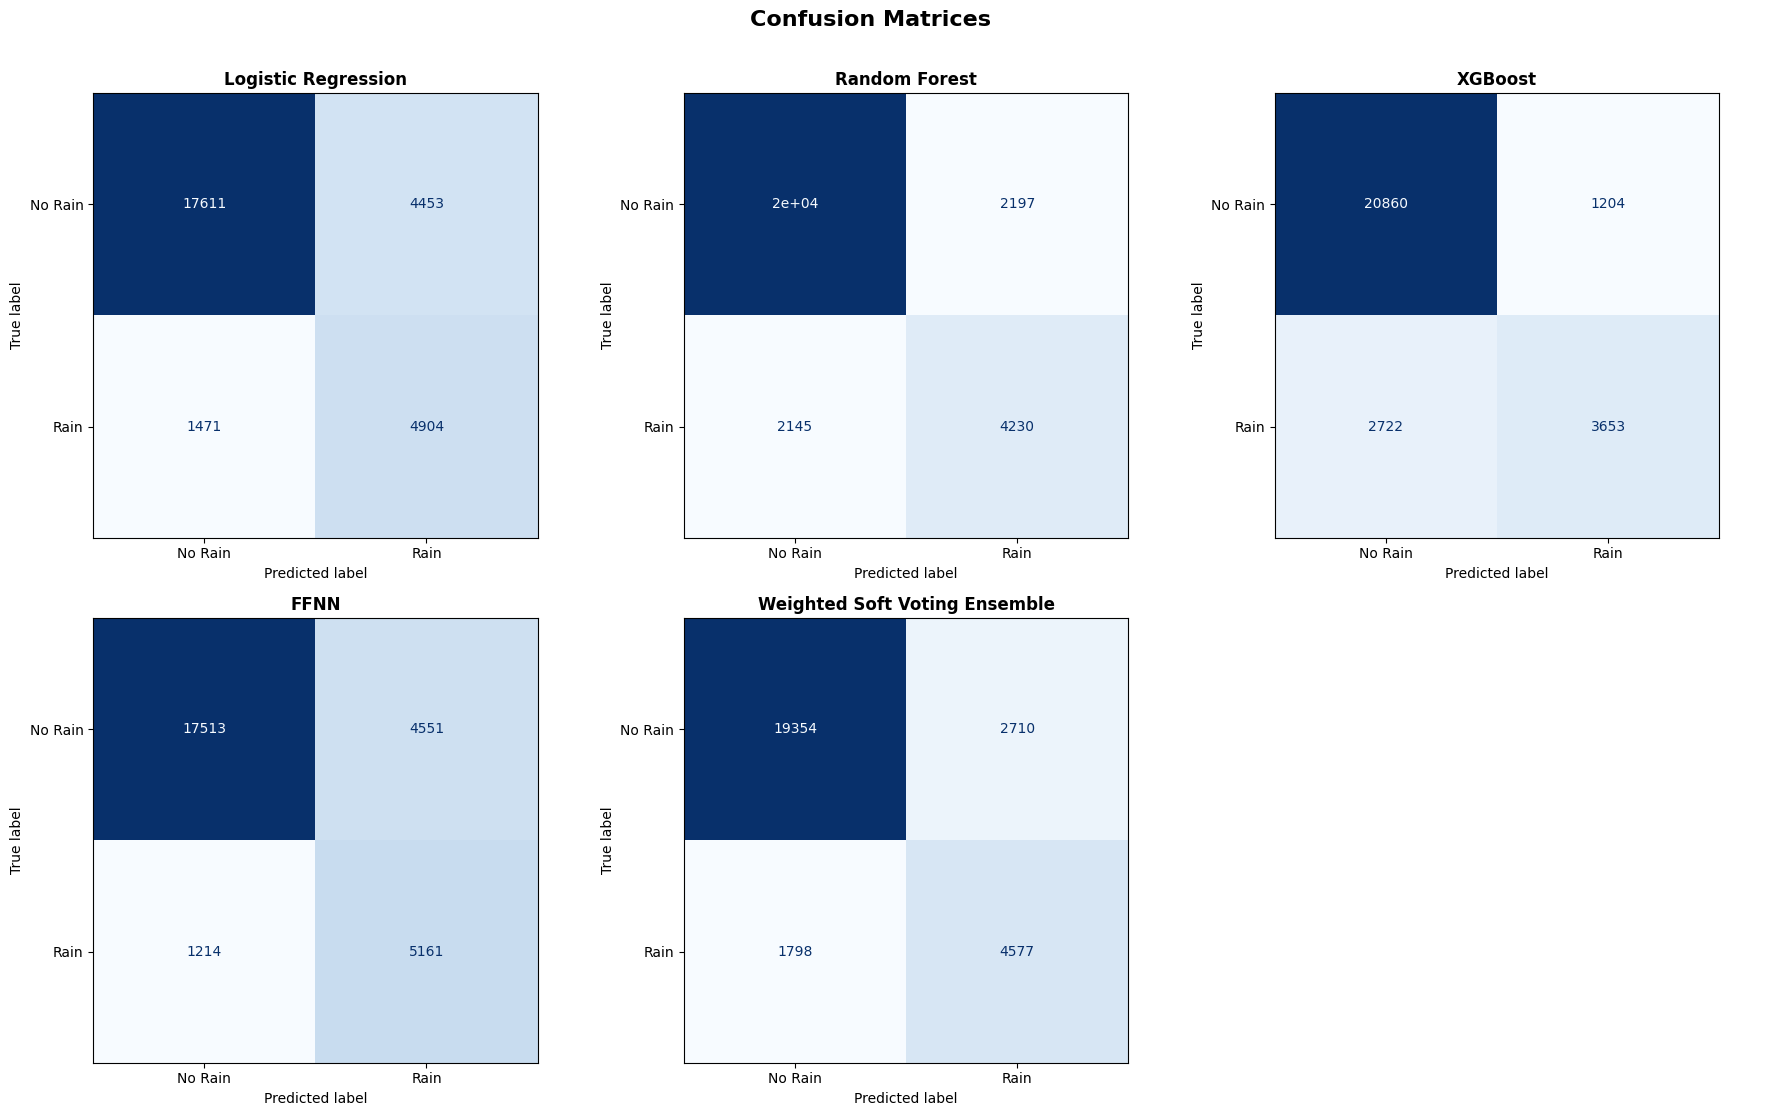

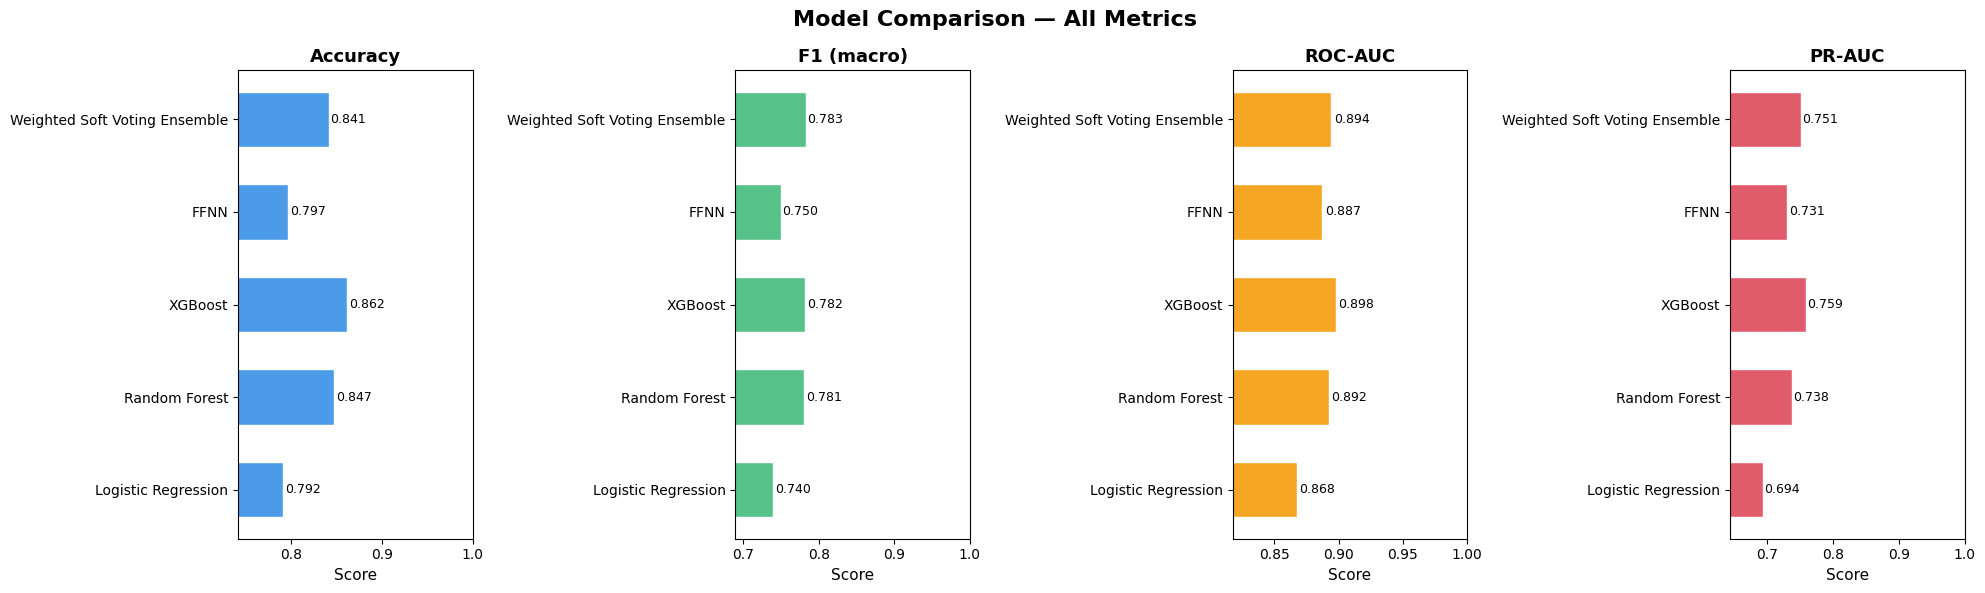

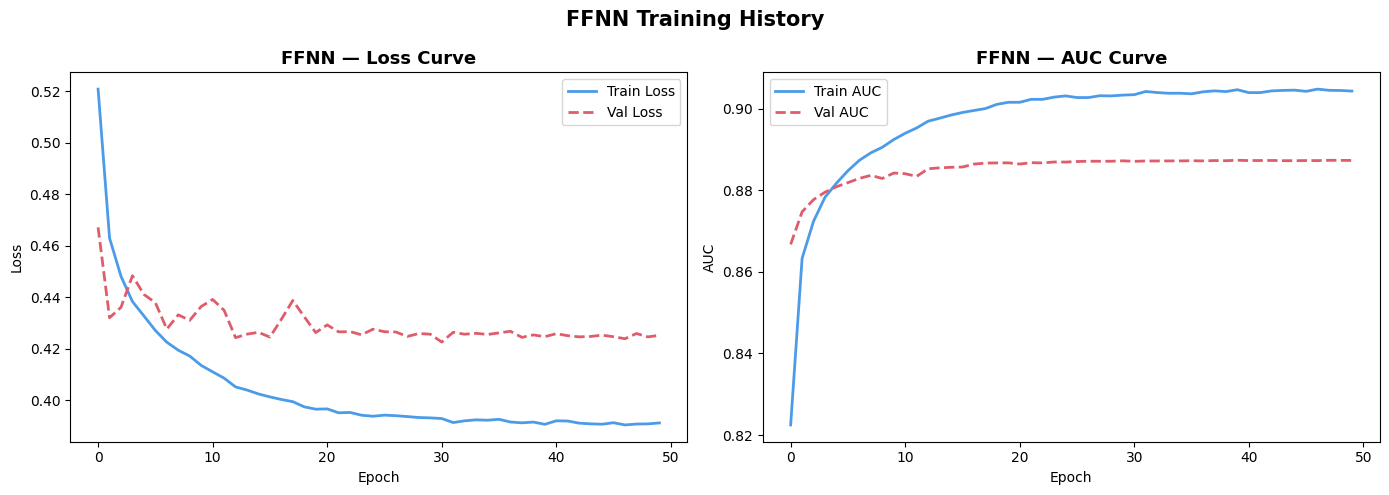

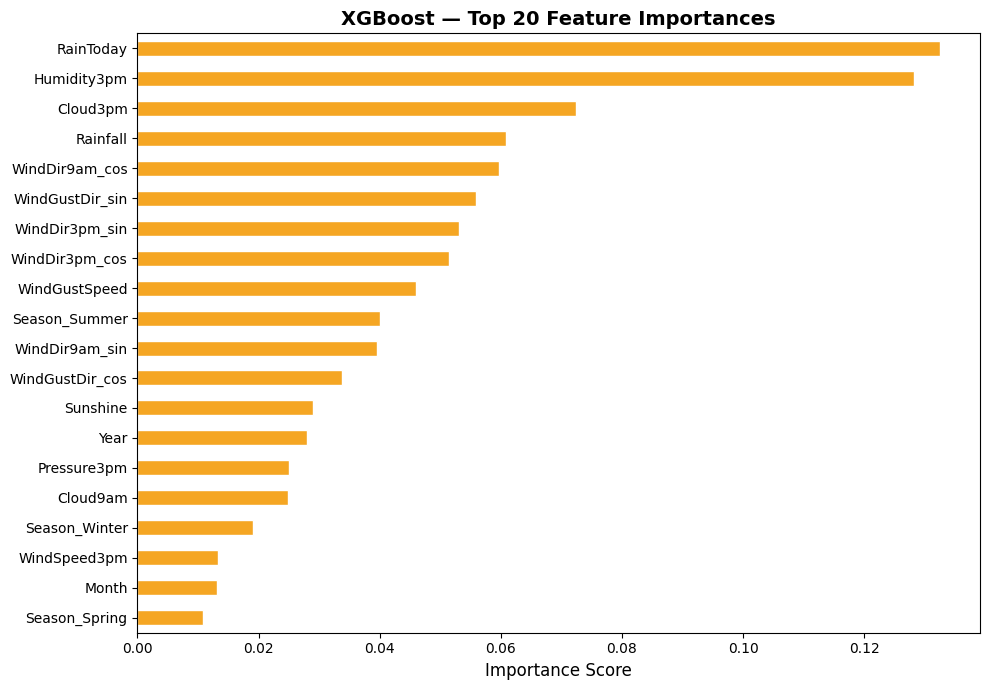

In [20]:
# ── 19. VISUALISATIONS ────────────────────────────────────────
print("\n>>> Generating visualisation plots...")
 
all_results = [lr_results, rf_results, xgb_results, ffnn_results, ensemble_results]
colors_map  = {
    "Logistic Regression": "#4C9BE8",
    "Random Forest":        "#56C28A",
    "XGBoost":              "#F5A623",
    "FFNN":                 "#E05C6B",
    "Weighted Soft Voting Ensemble": "#9B59B6"
}
 
# ---- Fig 1: ROC Curves ----
plt.figure(figsize=(9, 7))
for r in all_results:
    fpr, tpr, _ = roc_curve(y_test, r["y_proba"])
    plt.plot(fpr, tpr, lw=2,
             color=colors_map[r["name"]],
             label=f"{r['name']} (AUC={r['roc_auc']:.3f})")
plt.plot([0,1],[0,1],"k--", lw=1)
plt.xlabel("False Positive Rate", fontsize=13)
plt.ylabel("True Positive Rate",  fontsize=13)
plt.title("ROC Curves — All Models", fontsize=15, fontweight="bold")
plt.legend(loc="lower right", fontsize=10)
plt.tight_layout()
plt.savefig("/kaggle/working/roc_curves.png", dpi=150)
plt.show()
 
# ---- Fig 2: Precision-Recall Curves ----
plt.figure(figsize=(9, 7))
for r in all_results:
    prec, rec, _ = precision_recall_curve(y_test, r["y_proba"])
    plt.plot(rec, prec, lw=2,
             color=colors_map[r["name"]],
             label=f"{r['name']} (PR-AUC={r['pr_auc']:.3f})")
plt.xlabel("Recall",    fontsize=13)
plt.ylabel("Precision", fontsize=13)
plt.title("Precision-Recall Curves — All Models", fontsize=15, fontweight="bold")
plt.legend(loc="upper right", fontsize=10)
plt.tight_layout()
plt.savefig("/kaggle/working/pr_curves.png", dpi=150)
plt.show()
 
# ---- Fig 3: Confusion Matrices (all 5) ----
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
axes = axes.ravel()
for i, r in enumerate(all_results):
    disp = ConfusionMatrixDisplay(
        confusion_matrix=r["cm"],
        display_labels=["No Rain", "Rain"]
    )
    disp.plot(ax=axes[i], colorbar=False, cmap="Blues")
    axes[i].set_title(r["name"], fontsize=12, fontweight="bold")
axes[-1].axis("off")  # hide 6th panel
plt.suptitle("Confusion Matrices", fontsize=16, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("/kaggle/working/confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()
 
# ---- Fig 4: Metric Comparison Bar Chart ----
metrics_df = pd.DataFrame([{
    "Model":    r["name"],
    "Accuracy": r["accuracy"],
    "F1 (macro)": r["f1"],
    "ROC-AUC":  r["roc_auc"],
    "PR-AUC":   r["pr_auc"]
} for r in all_results]).set_index("Model")
 
fig, axes = plt.subplots(1, 4, figsize=(20, 6), sharey=False)
metric_cols   = ["Accuracy", "F1 (macro)", "ROC-AUC", "PR-AUC"]
metric_colors = ["#4C9BE8", "#56C28A", "#F5A623", "#E05C6B"]
 
for ax, col, color in zip(axes, metric_cols, metric_colors):
    bars = ax.barh(metrics_df.index, metrics_df[col],
                   color=color, edgecolor="white", height=0.6)
    ax.set_xlim(metrics_df[col].min() - 0.05, 1.0)
    ax.set_title(col, fontsize=13, fontweight="bold")
    ax.set_xlabel("Score", fontsize=11)
    for bar, val in zip(bars, metrics_df[col]):
        ax.text(val + 0.002, bar.get_y() + bar.get_height()/2,
                f"{val:.3f}", va="center", fontsize=9)
 
plt.suptitle("Model Comparison — All Metrics", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.savefig("/kaggle/working/metric_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
 
# ---- Fig 5: FFNN Training History ----
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(history.history["loss"],     label="Train Loss",  color="#4C9BE8", lw=2)
ax1.plot(history.history["val_loss"], label="Val Loss",    color="#E05C6B", lw=2, ls="--")
ax1.set_title("FFNN — Loss Curve",      fontsize=13, fontweight="bold")
ax1.set_xlabel("Epoch"); ax1.set_ylabel("Loss")
ax1.legend()
 
ax2.plot(history.history["auc"],     label="Train AUC", color="#4C9BE8", lw=2)
ax2.plot(history.history["val_auc"], label="Val AUC",   color="#E05C6B", lw=2, ls="--")
ax2.set_title("FFNN — AUC Curve",       fontsize=13, fontweight="bold")
ax2.set_xlabel("Epoch"); ax2.set_ylabel("AUC")
ax2.legend()
 
plt.suptitle("FFNN Training History", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.savefig("/kaggle/working/ffnn_history.png", dpi=150)
plt.show()
 
# ---- Fig 6: XGBoost Feature Importance ----
feat_imp = pd.Series(
    xgb.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False).head(20)
 
plt.figure(figsize=(10, 7))
feat_imp.sort_values().plot(
    kind="barh", color="#F5A623", edgecolor="white"
)
plt.title("XGBoost — Top 20 Feature Importances",
          fontsize=14, fontweight="bold")
plt.xlabel("Importance Score", fontsize=12)
plt.tight_layout()
plt.savefig("/kaggle/working/feature_importance.png", dpi=150)
plt.show()

In [21]:
# ── 20. FINAL SUMMARY TABLE ───────────────────────────────────
print("\n" + "="*65)
print("  FINAL MODEL COMPARISON SUMMARY")
print("="*65)
summary = pd.DataFrame([{
    "Model":      r["name"],
    "Accuracy":   f"{r['accuracy']:.4f}",
    "F1 (macro)": f"{r['f1']:.4f}",
    "ROC-AUC":    f"{r['roc_auc']:.4f}",
    "PR-AUC":     f"{r['pr_auc']:.4f}"
} for r in all_results])
summary.set_index("Model", inplace=True)
print(summary.to_string())
print("="*65)
 
print("\nAll outputs saved to /kaggle/working/")
print("Pipeline complete ✓")


  FINAL MODEL COMPARISON SUMMARY
                              Accuracy F1 (macro) ROC-AUC  PR-AUC
Model                                                            
Logistic Regression             0.7917     0.7397  0.8676  0.6939
Random Forest                   0.8473     0.7812  0.8922  0.7384
XGBoost                         0.8620     0.7822  0.8977  0.7588
FFNN                            0.7973     0.7502  0.8874  0.7312
Weighted Soft Voting Ensemble   0.8415     0.7829  0.8944  0.7511

All outputs saved to /kaggle/working/
Pipeline complete ✓
